# Diffusion-TS: Interpretable Diffusion with Conditional Generation

**Chapter 5: Synthetic Data Generation**
**Section Reference**: Section 5.5 (Diffusion Models for Financial Time Series)

**Docker image**: `ml4t-gpu`

> **GPU recommended**: This notebook trains models with PyTorch/CUDA. It will run on CPU
> but training may be very slow. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 05_synthetic_data/05_diffusion_ts.py
> ```


## Purpose

This notebook implements **Diffusion-TS** (Yuan & Qiao, ICLR 2024), a diffusion
model that decomposes the denoising prediction into **trend** (polynomial regression)
and **seasonal** (Fourier basis) components. This interpretable structure encourages
the model to separate slow drift from periodic patterns, analogous to classical STL
decomposition but learned end-to-end within the diffusion framework.

Unlike vanilla diffusion models that predict noise $\varepsilon$, Diffusion-TS
predicts $x_0$ directly. The Fourier-domain loss further regularizes spectral
fidelity -- critical for preserving autocorrelation structure in financial returns.

## Learning Objectives

By completing this notebook, you will:
- Implement a diffusion model with **interpretable trend+seasonal decomposition**
- Train with a combined **time-domain + Fourier-domain** loss
- Use **DDIM** fast sampling to reduce generation from 500 to 50 reverse steps
- Build a **regime classifier** on noised data and apply **classifier guidance**
  to generate regime-conditional synthetic returns
- Evaluate unconditional and conditional generation quality

## Cross-References

- **Upstream**: ETF Universe loader (`data`)
- **Downstream**: Regime-conditioned synthetic data for stress testing (Ch 20)
- **Book**: Section 5.5 discusses diffusion + conditional generation
- **Related**: [`02_tailgan_tail_risk`](02_tailgan_tail_risk.ipynb) (GAN), [`03_sigcwgan_signatures`](03_sigcwgan_signatures.ipynb) (GAN)

---

## From GANs to Interpretable Diffusion

GANs face training instability, mode collapse, and limited interpretability.
Diffusion models solve the first two by replacing adversarial training with a
simple regression objective. Diffusion-TS goes further by decomposing the
denoising network's output into components with known semantics:

$$\hat{x}_0 = \text{Trend}(z) + \text{Season}(z) + \text{Residual}(z)$$

where $z$ is the latent representation at diffusion step $t$. The trend block
uses polynomial regression, the seasonal block selects top-$k$ Fourier modes,
and the residual captures everything else. This makes the model's behavior
inspectable -- you can visualize what the model attributes to drift versus
cyclical patterns.

## References

- **Paper**: Yuan, X. & Qiao, Y. (2024). "Diffusion-TS: Interpretable Diffusion
  for General Time Series Generation." ICLR 2024.
- **Code**: https://github.com/Y-debug-sys/Diffusion-TS

## Key Adaptation Decisions

1. **No clamp(-1, 1)**: The original code clamps predicted $x_0$ to [-1, 1] for
   image-like data. Financial returns are StandardScaler-normalized (unbounded),
   so we remove the clamp entirely.
2. **Predict $x_0$** (not noise): The model outputs $\hat{x}_0 = \text{trend} +
   \text{season}$, then derives noise analytically. This pairs naturally with the
   decomposition.
3. **Fourier loss preserved**: The frequency-domain regularizer matches spectral
   properties -- essential for autocorrelation fidelity in returns.
4. **Classifier guidance**: A separate Transformer classifier trained on noised
   sequences enables regime-conditional generation at sampling time.

In [1]:
"""Diffusion-TS: Interpretable Diffusion with Conditional Generation."""

import json
import math
import warnings
from copy import deepcopy
from datetime import UTC, datetime
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from einops import rearrange, reduce, repeat
from hmmlearn.hmm import GaussianHMM
from IPython.display import Image, display
from scipy import stats
from scipy.stats import kurtosis as calc_kurtosis
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from data import load_etfs
from utils.paths import get_chapter_dir, get_output_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, plot_fidelity_comparison

## Diffusion Process Overview

Diffusion models work by gradually adding noise (forward process) and then
learning to reverse it (denoising). Diffusion-TS adds interpretable
trend+seasonal decomposition to the denoiser.

In [2]:
ASSETS_DIR = get_chapter_dir(5) / "assets"
if (ASSETS_DIR / "diffusion_forward_reverse.jpeg").exists():
    display(Image(ASSETS_DIR / "diffusion_forward_reverse.jpeg", width=800))

## Configuration

The original Diffusion-TS paper uses seq_length=24, 6 stocks, and 10,000 epochs.
We adapt for financial applications with the following considerations:

| Parameter | Paper | Ours | Rationale |
|-----------|-------|------|-----------|
| seq_length | 24 | 60 | ~3 months of trading context |
| feature_size | 6 | 20 | Balance diversity vs complexity |
| epochs | 10,000 | 10,000 | Match paper for convergence |
| lr | 1e-5→8e-4 | 1e-5→8e-4 | Warmup schedule from paper |

With 20 assets × 60 timesteps = 1,200 values per sample (vs paper's 144),
we train longer to capture the richer cross-asset structure.

In [3]:
# Production defaults (Yuan & Qiao, ICLR 2024)
SEQ_LENGTH = 60  # ~3 months of trading context (paper uses 24)
FEATURE_SIZE = 20  # Number of ETFs (paper uses 6)
N_LAYER_DEC = 4  # Decoder layers (paper uses 2; we use 4 for more capacity)
TIMESTEPS = 500  # Forward diffusion steps
SAMPLING_TIMESTEPS = 50  # DDIM fast sampling steps
EPOCHS = 10000  # Training epochs (paper uses 10000)
BATCH_SIZE = 64  # Training batch size
WARMUP_STEPS = 500  # LR warmup steps
GRADIENT_ACCUMULATE_EVERY = 2  # Gradient accumulation steps
CLASSIFIER_EPOCHS = 1500  # Regime classifier training epochs
SCHEDULER_PATIENCE = 500  # ReduceLROnPlateau patience
N_SYNTHETIC = 500  # Number of unconditional synthetic sequences
N_COND = 100  # Number of conditional samples per regime
SEED = 42

In [4]:
set_global_seeds(SEED)

# Configuration
RETRAIN = False  # Set True to retrain even if checkpoint exists

CONFIG = {
    # Sequence/architecture - scaled from paper (24×6) to financial use case
    "seq_length": SEQ_LENGTH,
    "feature_size": FEATURE_SIZE,
    "d_model": 64,
    "n_heads": 4,
    "n_layer_enc": 2,
    "n_layer_dec": N_LAYER_DEC,
    # Diffusion process
    "timesteps": TIMESTEPS,
    "sampling_timesteps": SAMPLING_TIMESTEPS,
    "eta": 0.0,  # Deterministic DDIM (eta=1 made variance worse, not better)
    "beta_schedule": "cosine",
    "loss_type": "l1",
    # Training - match paper's schedule
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "lr": 1e-5,  # Paper's base_lr (not warmup target)
    "warmup_lr": 8e-4,  # Paper's warmup target
    "warmup_steps": WARMUP_STEPS,
    "ema_decay": 0.995,
    "gradient_accumulate_every": GRADIENT_ACCUMULATE_EVERY,
    # Data split
    "start_date": "2005-01-01",
    "holdout_start": "2024-01-01",
    # Classifier guidance for regime-conditional generation
    "classifier_epochs": CLASSIFIER_EPOCHS,
    "classifier_lr": 5e-4,
    # Regime-specific guidance: minority class (high-vol) needs gentler steering
    # to prevent mode collapse (all samples pushed to extreme volatility).
    # Low-Vol (majority): standard guidance, temperature=1, eta=0.5
    # High-Vol (minority): lower scale, higher temperature for diversity, eta=0.7
    "guidance_settings": {
        0: {"scale": 0.75, "temperature": 1.0, "eta": 0.5},  # Low-Vol
        1: {"scale": 0.3, "temperature": 2.0, "eta": 0.7},  # High-Vol: gentler
    },
    "n_regimes": 2,  # Low-Vol vs High-Vol (imbalanced data precludes 3-way)
}

In [5]:
# Output paths and reproducibility
OUTPUT_DIR = get_output_dir(5, "diffusion_ts")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / "diffusion_ts_model.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Data Loading and Preparation

We load daily ETF returns and create overlapping sequences. The temporal
train/holdout split at 2024-01-01 ensures unbiased TSTR evaluation.

In [6]:
def load_returns_data(start_date: str, n_assets: int) -> tuple[np.ndarray, np.ndarray, list[str]]:
    """Load daily returns for ETF assets with temporal split."""
    df = load_etfs()
    start_dt = pl.lit(start_date).str.to_date()

    returns_df = (
        df.filter(pl.col("timestamp") >= start_dt)
        .sort(["symbol", "timestamp"])
        .with_columns(pl.col("close").pct_change().over("symbol").alias("return"))
        .pivot(on="symbol", index="timestamp", values="return")
        .sort("timestamp")
        .drop_nulls()
    )

    data_cols = [c for c in returns_df.columns if c != "timestamp"][:n_assets]
    timestamps = returns_df.select("timestamp").to_numpy().flatten()
    returns = returns_df.select(data_cols).to_numpy().astype(np.float32)

    print(f"Loaded {len(returns)} days of returns for {len(data_cols)} assets")
    print(f"Date range: {timestamps[0]} to {timestamps[-1]}")
    return returns, timestamps, data_cols

### Create Overlapping Sequences

Sliding windows maximize sample count from limited financial data.

In [7]:
def create_sequences(data: np.ndarray, seq_length: int) -> np.ndarray:
    """Create overlapping sequences from time series data."""
    n_seq = len(data) - seq_length + 1
    seqs = np.zeros((n_seq, seq_length, data.shape[1]), dtype=np.float32)
    for i in range(n_seq):
        seqs[i] = data[i : i + seq_length]
    return seqs

In [8]:
all_returns, all_timestamps, asset_names = load_returns_data(
    CONFIG["start_date"], CONFIG["feature_size"]
)
n_assets = all_returns.shape[1]

# Temporal split
holdout_dt = np.datetime64(CONFIG["holdout_start"])
train_mask = all_timestamps < holdout_dt

returns = all_returns[train_mask]
holdout_returns = all_returns[~train_mask]

print(f"\nTrain: {len(returns):,} days | Holdout: {len(holdout_returns):,} days")

sequences = create_sequences(returns, CONFIG["seq_length"])
holdout_sequences = create_sequences(holdout_returns, CONFIG["seq_length"])
print(f"Train sequences: {sequences.shape} | Holdout: {holdout_sequences.shape}")

Loaded 1894 days of returns for 20 assets
Date range: 2018-06-20 to 2025-12-31

Train: 1,392 days | Holdout: 502 days
Train sequences: (1333, 60, 20) | Holdout: (443, 60, 20)


## 2. Utility Modules

These building blocks support the Transformer architecture: sinusoidal
timestep embeddings, learnable positional encoding, and adaptive layer
normalization that conditions on the diffusion timestep.

In [9]:
# Inline helpers (from Diffusion-TS model_utils)
def extract(a, t, x_shape):
    """Gather values from `a` at indices `t`, reshape for broadcasting."""
    b, *_ = t.shape
    out = a.gather(-1, t)
    return out.reshape(b, *((1,) * (len(x_shape) - 1)))

In [10]:
class SinusoidalPosEmb(nn.Module):
    """Sinusoidal positional embedding for diffusion timestep."""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=x.device) * -emb)
        emb = x[:, None] * emb[None, :]
        return torch.cat((emb.sin(), emb.cos()), dim=-1)

### Adaptive Layer Normalization

AdaLayerNorm modulates the normalized activations by a scale and shift
derived from the diffusion timestep embedding. This gives each Transformer
layer information about the current noise level.

In [11]:
class AdaLayerNorm(nn.Module):
    """Layer norm conditioned on diffusion timestep via scale+shift."""

    def __init__(self, n_embd):
        super().__init__()
        self.emb = SinusoidalPosEmb(n_embd)
        self.silu = nn.SiLU()
        self.linear = nn.Linear(n_embd, n_embd * 2)
        self.layernorm = nn.LayerNorm(n_embd, elementwise_affine=False)

    def forward(self, x, timestep, label_emb=None):
        emb = self.emb(timestep)
        if label_emb is not None:
            emb = emb + label_emb
        emb = self.linear(self.silu(emb)).unsqueeze(1)
        scale, shift = torch.chunk(emb, 2, dim=2)
        return self.layernorm(x) * (1 + scale) + shift

### Learnable Positional Encoding and Conv Embedding

LearnablePositionalEncoding adds a learned position vector to each timestep.
Conv_MLP projects the input feature dimension to the model dimension using
a 1D convolution, which captures local patterns in the feature axis.

In [12]:
class LearnablePositionalEncoding(nn.Module):
    """Learned positional encoding added to sequence embeddings."""

    def __init__(self, d_model, dropout=0.1, max_len=1024):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        self.pe = nn.Parameter(torch.empty(1, max_len, d_model))
        nn.init.uniform_(self.pe, -0.02, 0.02)

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])

In [13]:
class Transpose(nn.Module):
    """Transpose wrapper for use in nn.Sequential."""

    def __init__(self, shape: tuple):
        super().__init__()
        self.shape = shape

    def forward(self, x):
        return x.transpose(*self.shape)

In [14]:
class Conv_MLP(nn.Module):
    """1D convolution embedding: features → model dimension."""

    def __init__(self, in_dim, out_dim, resid_pdrop=0.0):
        super().__init__()
        self.sequential = nn.Sequential(
            Transpose(shape=(1, 2)),
            nn.Conv1d(in_dim, out_dim, 3, stride=1, padding=1),
            nn.Dropout(p=resid_pdrop),
        )

    def forward(self, x):
        return self.sequential(x).transpose(1, 2)

## 3. Interpretable Decomposition

The key innovation of Diffusion-TS: each decoder layer extracts **trend**
and **seasonal** components from its intermediate representation.

- **TrendBlock**: Learns a polynomial basis (degree 3) via 1D convolutions,
  then multiplies by a polynomial space $[t, t^2, t^3]$ to produce a smooth trend.
- **FourierLayer**: Computes the DFT of the latent, selects top-$k$ frequencies
  by magnitude, then reconstructs via inverse DFT. This extracts dominant
  periodic patterns without assuming a fixed period.

Across decoder layers, trend and seasonal residuals accumulate, building up
the full decomposition progressively.

In [15]:
class TrendBlock(nn.Module):
    """Polynomial regression on latent representation → smooth trend."""

    def __init__(self, in_dim, out_dim, in_feat, out_feat, act):
        super().__init__()
        trend_poly = 3
        self.trend = nn.Sequential(
            nn.Conv1d(in_channels=in_dim, out_channels=trend_poly, kernel_size=3, padding=1),
            act,
            Transpose(shape=(1, 2)),
            nn.Conv1d(in_feat, out_feat, 3, stride=1, padding=1),
        )
        lin_space = torch.arange(1, out_dim + 1, 1) / (out_dim + 1)
        self.poly_space = torch.stack([lin_space ** float(p + 1) for p in range(trend_poly)], dim=0)

    def forward(self, x):
        x = self.trend(x).transpose(1, 2)
        trend_vals = torch.matmul(x.transpose(1, 2), self.poly_space.to(x.device))
        return trend_vals.transpose(1, 2)

### FourierLayer: Top-k Frequency Selection

Rather than using all Fourier coefficients, the layer selects the top-$k$
frequencies (by magnitude) and reconstructs only those. This acts as a
learned bandpass filter that adapts to the data's spectral content.

In [16]:
class FourierLayer(nn.Module):
    """Extract seasonal component via top-k inverse DFT."""

    def __init__(self, d_model, low_freq=1, factor=1):
        super().__init__()
        self.d_model = d_model
        self.factor = factor
        self.low_freq = low_freq

    def forward(self, x):
        """x: (b, t, d)"""
        b, t, d = x.shape
        x_freq = torch.fft.rfft(x, dim=1)

        if t % 2 == 0:
            x_freq = x_freq[:, self.low_freq : -1]
            f = torch.fft.rfftfreq(t)[self.low_freq : -1]
        else:
            x_freq = x_freq[:, self.low_freq :]
            f = torch.fft.rfftfreq(t)[self.low_freq :]

        x_freq, index_tuple = self.topk_freq(x_freq)
        f = repeat(f, "f -> b f d", b=x_freq.size(0), d=x_freq.size(2)).to(x_freq.device)
        f = rearrange(f[index_tuple], "b f d -> b f () d").to(x_freq.device)
        return self.extrapolate(x_freq, f, t)

    def extrapolate(self, x_freq, f, t):
        x_freq = torch.cat([x_freq, x_freq.conj()], dim=1)
        f = torch.cat([f, -f], dim=1)
        t_range = rearrange(torch.arange(t, dtype=torch.float), "t -> () () t ()").to(x_freq.device)
        amp = rearrange(x_freq.abs(), "b f d -> b f () d")
        phase = rearrange(x_freq.angle(), "b f d -> b f () d")
        x_time = amp * torch.cos(2 * math.pi * f * t_range + phase)
        return reduce(x_time, "b f t d -> b t d", "sum")

    def topk_freq(self, x_freq):
        length = x_freq.shape[1]
        top_k = int(self.factor * math.log(max(length, 2)))
        top_k = max(top_k, 1)
        values, indices = torch.topk(x_freq.abs(), top_k, dim=1, largest=True, sorted=True)
        mesh_a, mesh_b = torch.meshgrid(
            torch.arange(x_freq.size(0)), torch.arange(x_freq.size(2)), indexing="ij"
        )
        index_tuple = (mesh_a.unsqueeze(1), indices, mesh_b.unsqueeze(1))
        x_freq = x_freq[index_tuple]
        return x_freq, index_tuple

## 4. Transformer Architecture

The encoder-decoder Transformer processes noised sequences. The **encoder**
creates a contextual representation conditioned on the diffusion timestep.
The **decoder** cross-attends to the encoder output and, at each layer,
extracts trend and seasonal residuals that accumulate across layers.

In [17]:
class FullAttention(nn.Module):
    """Multi-head self-attention."""

    def __init__(self, n_embd, n_head, attn_pdrop=0.0, resid_pdrop=0.0):
        super().__init__()
        assert n_embd % n_head == 0
        self.key = nn.Linear(n_embd, n_embd)
        self.query = nn.Linear(n_embd, n_embd)
        self.value = nn.Linear(n_embd, n_embd)
        self.attn_drop = nn.Dropout(attn_pdrop)
        self.resid_drop = nn.Dropout(resid_pdrop)
        self.proj = nn.Linear(n_embd, n_embd)
        self.n_head = n_head

    def forward(self, x, mask=None):
        B, T, C = x.size()
        k = self.key(x).view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = self.query(x).view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = self.value(x).view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.proj(y))

### Cross-Attention

The decoder cross-attends to the encoder's output. Queries come from the
decoder, while keys and values come from the encoder -- this lets each
decoder position gather relevant context from the full encoded sequence.

In [18]:
class CrossAttention(nn.Module):
    """Multi-head cross-attention (decoder queries, encoder keys/values)."""

    def __init__(self, n_embd, condition_embd, n_head, attn_pdrop=0.0, resid_pdrop=0.0):
        super().__init__()
        assert n_embd % n_head == 0
        self.key = nn.Linear(condition_embd, n_embd)
        self.query = nn.Linear(n_embd, n_embd)
        self.value = nn.Linear(condition_embd, n_embd)
        self.attn_drop = nn.Dropout(attn_pdrop)
        self.resid_drop = nn.Dropout(resid_pdrop)
        self.proj = nn.Linear(n_embd, n_embd)
        self.n_head = n_head

    def forward(self, x, encoder_output, mask=None):
        B, T, C = x.size()
        B, T_E, _ = encoder_output.size()
        k = self.key(encoder_output).view(B, T_E, self.n_head, C // self.n_head).transpose(1, 2)
        q = self.query(x).view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = self.value(encoder_output).view(B, T_E, self.n_head, C // self.n_head).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.proj(y))

### Encoder and Decoder Blocks

Each encoder block applies adaptive layer norm → self-attention → FFN.
Each decoder block adds cross-attention to the encoder output, then
splits the representation into two branches: one for trend extraction
(polynomial regression) and one for seasonal extraction (Fourier layer).

In [19]:
class EncoderBlock(nn.Module):
    """Transformer encoder block with timestep-conditioned AdaLayerNorm."""

    def __init__(self, n_embd=64, n_head=4, attn_pdrop=0.0, resid_pdrop=0.0, mlp_hidden_times=4):
        super().__init__()
        self.ln1 = AdaLayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
        self.attn = FullAttention(n_embd, n_head, attn_pdrop, resid_pdrop)
        self.mlp = nn.Sequential(
            nn.Linear(n_embd, mlp_hidden_times * n_embd),
            nn.GELU(),
            nn.Linear(mlp_hidden_times * n_embd, n_embd),
            nn.Dropout(resid_pdrop),
        )

    def forward(self, x, timestep, mask=None):
        x = x + self.attn(self.ln1(x, timestep), mask=mask)
        x = x + self.mlp(self.ln2(x))
        return x

In [20]:
class Encoder(nn.Module):
    """Stack of encoder blocks."""

    def __init__(self, n_layer=2, n_embd=64, n_head=4, attn_pdrop=0.0, resid_pdrop=0.0):
        super().__init__()
        self.blocks = nn.ModuleList(
            [EncoderBlock(n_embd, n_head, attn_pdrop, resid_pdrop) for _ in range(n_layer)]
        )

    def forward(self, x, t):
        for block in self.blocks:
            x = block(x, t)
        return x

In [21]:
class DecoderBlock(nn.Module):
    """Decoder block: self-attn + cross-attn + trend/season extraction."""

    def __init__(
        self,
        n_channel,
        n_feat,
        n_embd=64,
        n_head=4,
        attn_pdrop=0.0,
        resid_pdrop=0.0,
        mlp_hidden_times=4,
        condition_dim=64,
    ):
        super().__init__()
        self.ln1 = AdaLayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ln1_1 = AdaLayerNorm(n_embd)

        self.attn1 = FullAttention(n_embd, n_head, attn_pdrop, resid_pdrop)
        self.attn2 = CrossAttention(n_embd, condition_dim, n_head, attn_pdrop, resid_pdrop)

        act = nn.GELU()
        self.trend = TrendBlock(n_channel, n_channel, n_embd, n_feat, act=act)
        self.seasonal = FourierLayer(d_model=n_embd)

        self.mlp = nn.Sequential(
            nn.Linear(n_embd, mlp_hidden_times * n_embd),
            nn.GELU(),
            nn.Linear(mlp_hidden_times * n_embd, n_embd),
            nn.Dropout(resid_pdrop),
        )
        self.proj = nn.Conv1d(n_channel, n_channel * 2, 1)
        self.linear = nn.Linear(n_embd, n_feat)

    def forward(self, x, encoder_output, timestep, mask=None):
        x = x + self.attn1(self.ln1(x, timestep), mask=mask)
        x = x + self.attn2(self.ln1_1(x, timestep), encoder_output, mask=mask)
        x1, x2 = self.proj(x).chunk(2, dim=1)
        trend, season = self.trend(x1), self.seasonal(x2)
        x = x + self.mlp(self.ln2(x))
        m = torch.mean(x, dim=1, keepdim=True)
        return x - m, self.linear(m), trend, season

In [22]:
class Decoder(nn.Module):
    """Stack of decoder blocks, accumulating trend and seasonal components."""

    def __init__(
        self,
        n_channel,
        n_feat,
        n_embd=64,
        n_head=4,
        n_layer=4,
        attn_pdrop=0.0,
        resid_pdrop=0.0,
        condition_dim=64,
    ):
        super().__init__()
        self.d_model = n_embd
        self.n_feat = n_feat
        self.blocks = nn.ModuleList(
            [
                DecoderBlock(
                    n_feat=n_feat,
                    n_channel=n_channel,
                    n_embd=n_embd,
                    n_head=n_head,
                    attn_pdrop=attn_pdrop,
                    resid_pdrop=resid_pdrop,
                    condition_dim=condition_dim,
                )
                for _ in range(n_layer)
            ]
        )

    def forward(self, x, t, enc):
        b, c, _ = x.shape
        mean = []
        season = torch.zeros((b, c, self.d_model), device=x.device)
        trend = torch.zeros((b, c, self.n_feat), device=x.device)
        for block in self.blocks:
            x, residual_mean, residual_trend, residual_season = block(x, enc, t)
            season += residual_season
            trend += residual_trend
            mean.append(residual_mean)
        mean = torch.cat(mean, dim=1)
        return x, mean, trend, season

### Full Transformer

The Transformer wraps encoder and decoder with input/output projections.
The final output combines: (1) accumulated trend across decoder layers,
(2) seasonal component projected back to feature space, and (3) a residual
from the decoder output. This produces $\hat{x}_0 = \text{trend} + \text{season\_error}$.

In [23]:
class DiffusionTransformer(nn.Module):
    """Encoder-decoder Transformer with interpretable trend+seasonal decomposition."""

    def __init__(
        self,
        n_feat,
        n_channel,
        n_layer_enc=2,
        n_layer_dec=4,
        n_embd=64,
        n_heads=4,
        attn_pdrop=0.0,
        resid_pdrop=0.0,
        mlp_hidden_times=4,
        max_len=2048,
    ):
        super().__init__()
        self.emb = Conv_MLP(n_feat, n_embd, resid_pdrop=resid_pdrop)
        self.inverse = Conv_MLP(n_embd, n_feat, resid_pdrop=resid_pdrop)

        kernel_size, padding = (1, 0) if n_feat < 32 and n_channel < 64 else (5, 2)

        self.combine_s = nn.Conv1d(
            n_embd,
            n_feat,
            kernel_size=kernel_size,
            stride=1,
            padding=padding,
            padding_mode="circular",
            bias=False,
        )
        self.combine_m = nn.Conv1d(
            n_layer_dec,
            1,
            kernel_size=1,
            stride=1,
            padding=0,
            padding_mode="circular",
            bias=False,
        )

        self.encoder = Encoder(n_layer_enc, n_embd, n_heads, attn_pdrop, resid_pdrop)
        self.pos_enc = LearnablePositionalEncoding(n_embd, dropout=resid_pdrop, max_len=max_len)

        self.decoder = Decoder(
            n_channel,
            n_feat,
            n_embd,
            n_heads,
            n_layer_dec,
            attn_pdrop,
            resid_pdrop,
            condition_dim=n_embd,
        )
        self.pos_dec = LearnablePositionalEncoding(n_embd, dropout=resid_pdrop, max_len=max_len)

    def forward(self, x, t, return_res=False):
        emb = self.emb(x)
        inp_enc = self.pos_enc(emb)
        enc_cond = self.encoder(inp_enc, t)

        inp_dec = self.pos_dec(emb)
        output, mean, trend, season = self.decoder(inp_dec, t, enc_cond)

        res = self.inverse(output)
        res_m = torch.mean(res, dim=1, keepdim=True)
        season_error = self.combine_s(season.transpose(1, 2)).transpose(1, 2) + res - res_m
        trend = self.combine_m(mean) + res_m + trend

        if return_res:
            return trend, self.combine_s(season.transpose(1, 2)).transpose(1, 2), res - res_m

        return trend, season_error

## 5. Diffusion Process

The `DiffusionTS` class implements the full DDPM framework with $x_0$
prediction. Key methods:
- `q_sample`: Forward process -- add noise to clean data
- `model_predictions`: Get model's $\hat{x}_0$ and derived noise
- `p_mean_variance`: Compute posterior $p(x_{t-1}|x_t)$ -- **no clamp**
- `_train_loss`: L1 + Fourier loss (time + frequency domain)
- `fast_sample`: DDIM-style accelerated sampling

**Critical adaptation**: We remove `clamp(-1, 1)` from `p_mean_variance`
and `model_predictions`. Financial returns are StandardScaler-normalized
but unbounded -- clamping would truncate the distribution tails.

In [24]:
def cosine_beta_schedule(timesteps, s=0.008):
    """Cosine schedule (Nichol & Dhariwal 2021)."""
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, dtype=torch.float64)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0, 0.999)

In [25]:
class DiffusionTS(nn.Module):
    """Diffusion-TS: x_0-prediction diffusion with Fourier loss."""

    def __init__(
        self,
        seq_length,
        feature_size,
        n_layer_enc=2,
        n_layer_dec=4,
        d_model=64,
        timesteps=500,
        sampling_timesteps=None,
        loss_type="l1",
        n_heads=4,
        mlp_hidden_times=4,
        eta=0.0,
        reg_weight=None,
    ):
        super().__init__()
        self.eta = eta
        self.seq_length = seq_length
        self.feature_size = feature_size
        self.ff_weight = reg_weight if reg_weight is not None else math.sqrt(seq_length) / 5

        self.model = DiffusionTransformer(
            n_feat=feature_size,
            n_channel=seq_length,
            n_layer_enc=n_layer_enc,
            n_layer_dec=n_layer_dec,
            n_heads=n_heads,
            mlp_hidden_times=mlp_hidden_times,
            max_len=seq_length,
            n_embd=d_model,
        )

        betas = cosine_beta_schedule(timesteps)
        alphas = 1.0 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)

        self.num_timesteps = int(timesteps)
        self.loss_type = loss_type
        self.sampling_timesteps = (
            sampling_timesteps if sampling_timesteps is not None else timesteps
        )
        self.fast_sampling = self.sampling_timesteps < timesteps

        def register(name, val):
            self.register_buffer(name, val.to(torch.float32))

        register("betas", betas)
        register("alphas_cumprod", alphas_cumprod)
        register("alphas_cumprod_prev", alphas_cumprod_prev)
        register("sqrt_alphas_cumprod", torch.sqrt(alphas_cumprod))
        register("sqrt_one_minus_alphas_cumprod", torch.sqrt(1.0 - alphas_cumprod))
        register("log_one_minus_alphas_cumprod", torch.log(1.0 - alphas_cumprod))
        register("sqrt_recip_alphas_cumprod", torch.sqrt(1.0 / alphas_cumprod))
        register("sqrt_recipm1_alphas_cumprod", torch.sqrt(1.0 / alphas_cumprod - 1))

        posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
        register("posterior_variance", posterior_variance)
        register("posterior_log_variance_clipped", torch.log(posterior_variance.clamp(min=1e-20)))
        register(
            "posterior_mean_coef1",
            betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod),
        )
        register(
            "posterior_mean_coef2",
            (1.0 - alphas_cumprod_prev) * torch.sqrt(alphas) / (1.0 - alphas_cumprod),
        )
        register(
            "loss_weight",
            torch.sqrt(alphas) * torch.sqrt(1.0 - alphas_cumprod) / betas / 100,
        )

    def predict_noise_from_start(self, x_t, t, x0):
        return (extract(self.sqrt_recip_alphas_cumprod, t, x_t.shape) * x_t - x0) / extract(
            self.sqrt_recipm1_alphas_cumprod, t, x_t.shape
        )

    def q_posterior(self, x_start, x_t, t):
        posterior_mean = (
            extract(self.posterior_mean_coef1, t, x_t.shape) * x_start
            + extract(self.posterior_mean_coef2, t, x_t.shape) * x_t
        )
        posterior_variance = extract(self.posterior_variance, t, x_t.shape)
        posterior_log_variance = extract(self.posterior_log_variance_clipped, t, x_t.shape)
        return posterior_mean, posterior_variance, posterior_log_variance

    def output(self, x, t):
        """Model forward: predict x_0 as trend + season."""
        trend, season = self.model(x, t)
        return trend + season

    def model_predictions(self, x, t):
        """Predict x_0 (NO clamp -- returns are unbounded) and derive noise."""
        x_start = self.output(x, t)
        pred_noise = self.predict_noise_from_start(x, t, x_start)
        return pred_noise, x_start

    def p_mean_variance(self, x, t):
        """Posterior mean and variance -- NO clamp on x_start."""
        _, x_start = self.model_predictions(x, t)
        model_mean, posterior_variance, posterior_log_variance = self.q_posterior(
            x_start=x_start, x_t=x, t=t
        )
        return model_mean, posterior_variance, posterior_log_variance, x_start

    def p_sample(self, x, t: int, cond_fn=None, model_kwargs=None):
        """Single DDPM reverse step with optional classifier guidance."""
        batched_times = torch.full((x.shape[0],), t, device=x.device, dtype=torch.long)
        model_mean, _, model_log_variance, x_start = self.p_mean_variance(x=x, t=batched_times)
        noise = torch.randn_like(x) if t > 0 else 0.0
        if cond_fn is not None:
            model_mean = self.condition_mean(
                cond_fn,
                model_mean,
                model_log_variance,
                x,
                t=batched_times,
                model_kwargs=model_kwargs,
            )
        return model_mean + (0.5 * model_log_variance).exp() * noise, x_start

    @torch.no_grad()
    def sample(self, shape):
        """Full DDPM reverse sampling (all timesteps)."""
        img = torch.randn(shape, device=self.betas.device)
        for t in reversed(range(self.num_timesteps)):
            img, _ = self.p_sample(img, t)
        return img

    @torch.no_grad()
    def fast_sample(self, shape):
        """DDIM-style accelerated sampling."""
        batch, total_timesteps = shape[0], self.num_timesteps
        sampling_timesteps, eta = self.sampling_timesteps, self.eta

        times = torch.linspace(-1, total_timesteps - 1, steps=sampling_timesteps + 1)
        times = list(reversed(times.int().tolist()))
        time_pairs = list(zip(times[:-1], times[1:], strict=False))

        img = torch.randn(shape, device=self.betas.device)

        for time, time_next in time_pairs:
            time_cond = torch.full((batch,), time, device=self.betas.device, dtype=torch.long)
            pred_noise, x_start = self.model_predictions(img, time_cond)

            if time_next < 0:
                img = x_start
                continue

            alpha = self.alphas_cumprod[time]
            alpha_next = self.alphas_cumprod[time_next]
            sigma = eta * ((1 - alpha / alpha_next) * (1 - alpha_next) / (1 - alpha)).sqrt()
            c = (1 - alpha_next - sigma**2).sqrt()
            noise = torch.randn_like(img)
            img = x_start * alpha_next.sqrt() + c * pred_noise + sigma * noise

        return img

    @torch.no_grad()
    def fast_sample_cond(self, shape, cond_fn=None, model_kwargs=None, eta=None):
        """DDIM-style sampling with classifier guidance."""
        batch, total_timesteps = shape[0], self.num_timesteps
        sampling_timesteps = self.sampling_timesteps
        eta = eta if eta is not None else self.eta

        times = torch.linspace(-1, total_timesteps - 1, steps=sampling_timesteps + 1)
        times = list(reversed(times.int().tolist()))
        time_pairs = list(zip(times[:-1], times[1:], strict=False))

        img = torch.randn(shape, device=self.betas.device)

        for time, time_next in time_pairs:
            time_cond = torch.full((batch,), time, device=self.betas.device, dtype=torch.long)
            pred_noise, x_start = self.model_predictions(img, time_cond)

            if cond_fn is not None:
                _, x_start = self.condition_score(
                    cond_fn, x_start, img, time_cond, model_kwargs=model_kwargs
                )
                pred_noise = self.predict_noise_from_start(img, time_cond, x_start)

            if time_next < 0:
                img = x_start
                continue

            alpha = self.alphas_cumprod[time]
            alpha_next = self.alphas_cumprod[time_next]
            sigma = eta * ((1 - alpha / alpha_next) * (1 - alpha_next) / (1 - alpha)).sqrt()
            c = (1 - alpha_next - sigma**2).sqrt()
            noise = torch.randn_like(img)
            img = x_start * alpha_next.sqrt() + c * pred_noise + sigma * noise

        return img

    @torch.no_grad()
    def sample_cond(self, shape, cond_fn=None, model_kwargs=None, eta=None):
        """Full DDPM reverse sampling with classifier guidance.

        Note: eta parameter is ignored for full DDPM (inherently stochastic).
        """
        img = torch.randn(shape, device=self.betas.device)
        for t in reversed(range(self.num_timesteps)):
            img, _ = self.p_sample(img, t, cond_fn=cond_fn, model_kwargs=model_kwargs)
        return img

    def generate_mts(self, batch_size=16, model_kwargs=None, cond_fn=None, eta=None):
        """Entry point: generate multivariate time series.

        Args:
            eta: Stochasticity for DDIM sampling. eta=0 is deterministic, eta=1 is full DDPM.
                 For conditional sampling, eta>0 adds diversity and prevents mode collapse.
        """
        shape = (batch_size, self.seq_length, self.feature_size)
        if cond_fn is not None:
            sample_fn = self.fast_sample_cond if self.fast_sampling else self.sample_cond
            return sample_fn(shape, cond_fn=cond_fn, model_kwargs=model_kwargs, eta=eta)
        sample_fn = self.fast_sample if self.fast_sampling else self.sample
        return sample_fn(shape)

    @property
    def loss_fn(self):
        if self.loss_type == "l1":
            return F.l1_loss
        elif self.loss_type == "l2":
            return F.mse_loss
        raise ValueError(f"invalid loss type {self.loss_type}")

    def q_sample(self, x_start, t, noise=None):
        """Forward process: add noise to x_0."""
        if noise is None:
            noise = torch.randn_like(x_start)
        return (
            extract(self.sqrt_alphas_cumprod, t, x_start.shape) * x_start
            + extract(self.sqrt_one_minus_alphas_cumprod, t, x_start.shape) * noise
        )

    def _train_loss(self, x_start, t, target=None, noise=None):
        """Combined time-domain (L1) + frequency-domain (Fourier) loss."""
        if noise is None:
            noise = torch.randn_like(x_start)
        if target is None:
            target = x_start

        x = self.q_sample(x_start=x_start, t=t, noise=noise)
        model_out = self.output(x, t)

        train_loss = self.loss_fn(model_out, target, reduction="none")

        # Fourier loss: match spectral content
        fft1 = torch.fft.fft(model_out.transpose(1, 2), norm="forward")
        fft2 = torch.fft.fft(target.transpose(1, 2), norm="forward")
        fft1, fft2 = fft1.transpose(1, 2), fft2.transpose(1, 2)
        fourier_loss = self.loss_fn(
            torch.real(fft1), torch.real(fft2), reduction="none"
        ) + self.loss_fn(torch.imag(fft1), torch.imag(fft2), reduction="none")
        train_loss = train_loss + self.ff_weight * fourier_loss

        train_loss = reduce(train_loss, "b ... -> b (...)", "mean")
        train_loss = train_loss * extract(self.loss_weight, t, train_loss.shape)
        return train_loss.mean()

    def forward(self, x, **kwargs):
        b, c, n, device = *x.shape, x.device
        assert n == self.feature_size, f"expected {self.feature_size} features, got {n}"
        t = torch.randint(0, self.num_timesteps, (b,), device=device).long()
        return self._train_loss(x_start=x, t=t, **kwargs)

    def return_components(self, x, t: int):
        """Return trend, seasonal, residual decomposition for visualization."""
        b, c, n, device = *x.shape, x.device
        t_tensor = torch.tensor([t]).repeat(b).to(device)
        x_noised = self.q_sample(x, t_tensor)
        trend, season, residual = self.model(x_noised, t_tensor, return_res=True)
        return trend, season, residual, x_noised

    def condition_mean(self, cond_fn, mean, log_variance, x, t, model_kwargs=None):
        """Shift mean by σ² · ∇_x log p(y|x) for classifier guidance."""
        gradient = cond_fn(x=x, t=t, **(model_kwargs or {}))
        return mean.float() + torch.exp(log_variance) * gradient.float()

    def condition_score(self, cond_fn, x_start, x, t, model_kwargs=None):
        """Score-based conditioning (Song et al. 2020)."""
        alpha_bar = extract(self.alphas_cumprod, t, x.shape)
        eps = self.predict_noise_from_start(x, t, x_start)
        eps = eps - (1 - alpha_bar).sqrt() * cond_fn(x=x, t=t, **(model_kwargs or {}))
        pred_xstart = (
            extract(self.sqrt_recip_alphas_cumprod, t, x.shape) * x
            - extract(self.sqrt_recipm1_alphas_cumprod, t, x.shape) * eps
        )
        model_mean, _, _ = self.q_posterior(x_start=pred_xstart, x_t=x, t=t)
        return model_mean, pred_xstart

## 6. Exponential Moving Average

EMA maintains a shadow copy of model weights that is updated as a running
average: $\theta_{\text{ema}} \leftarrow \beta \theta_{\text{ema}} + (1-\beta) \theta$.
Sampling from the EMA model produces smoother, higher-quality outputs.

In [26]:
class EMA:
    """Simple exponential moving average of model parameters."""

    def __init__(self, model, decay=0.995, update_every=10):
        self.decay = decay
        self.update_every = update_every
        self.step = 0
        self.ema_model = deepcopy(model)
        self.ema_model.eval()
        for p in self.ema_model.parameters():
            p.requires_grad_(False)

    def update(self, model):
        self.step += 1
        if self.step % self.update_every != 0:
            return
        with torch.no_grad():
            for ema_p, model_p in zip(
                self.ema_model.parameters(), model.parameters(), strict=False
            ):
                ema_p.data.mul_(self.decay).add_(model_p.data, alpha=1.0 - self.decay)

    def to(self, device):
        self.ema_model = self.ema_model.to(device)
        return self

## 7. Training

Training follows the standard diffusion objective: sample a timestep $t$,
add noise to create $x_t$, predict $\hat{x}_0$, and minimize the combined
time-domain + Fourier loss. We use gradient clipping, warmup scheduler,
gradient accumulation, and EMA for stable convergence.

In [27]:
# Normalize data before training
scaler = StandardScaler()
scaler.fit(returns)  # Fit on raw returns, not sequences

seq_shape = sequences.shape
sequences_flat = sequences.reshape(-1, seq_shape[-1])
sequences_norm = scaler.transform(sequences_flat).reshape(seq_shape).astype(np.float32)

print(f"Normalized: mean={sequences_norm.mean():.4f}, std={sequences_norm.std():.4f}")

Normalized: mean=-0.0046, std=1.0091


In [28]:
# Initialize model
diffusion_model = DiffusionTS(
    seq_length=CONFIG["seq_length"],
    feature_size=n_assets,
    n_layer_enc=CONFIG["n_layer_enc"],
    n_layer_dec=CONFIG["n_layer_dec"],
    d_model=CONFIG["d_model"],
    timesteps=CONFIG["timesteps"],
    sampling_timesteps=CONFIG["sampling_timesteps"],
    eta=CONFIG["eta"],
    loss_type=CONFIG["loss_type"],
    n_heads=CONFIG["n_heads"],
).to(device)

n_params = sum(p.numel() for p in diffusion_model.parameters())
print(f"Model parameters: {n_params:,}")
print(f"DDIM: {CONFIG['timesteps']} training steps → {CONFIG['sampling_timesteps']} sampling steps")

Model parameters: 517,716
DDIM: 500 training steps → 50 sampling steps


### Checkpoint Loading

If a trained model exists and `RETRAIN=False`, we skip training and load
the saved weights. This allows iterating on evaluation/visualization
without retraining.

In [29]:
# Check for existing checkpoint
checkpoint_exists = CHECKPOINT_PATH.exists()
training_losses = []

if checkpoint_exists and not RETRAIN:
    print(f"Loading checkpoint from {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    diffusion_model.load_state_dict(checkpoint["model_state"])
    scaler = StandardScaler()
    scaler.mean_ = np.array(checkpoint["scaler_mean"])
    scaler.scale_ = np.array(checkpoint["scaler_scale"])
    training_losses = checkpoint.get("training_losses", [])
    print(f"Loaded model trained for {len(training_losses)} epochs")

    # Create EMA wrapper with loaded weights
    ema = EMA(diffusion_model, decay=CONFIG["ema_decay"]).to(device)
    ema.ema_model.load_state_dict(checkpoint["ema_state"])
    SKIP_TRAINING = True
else:
    if checkpoint_exists:
        print("RETRAIN=True: Ignoring existing checkpoint")
    else:
        print(f"No checkpoint found at {CHECKPOINT_PATH}")
    SKIP_TRAINING = False

Loading checkpoint from 05_synthetic_data/output/diffusion_ts/checkpoints/diffusion_ts_model.pt
Loaded model trained for 10000 epochs


In [30]:
# Create tensor data and utilities (needed for visualization/classifier even when loading from checkpoint)
tensor_data = torch.FloatTensor(sequences_norm).to(device)
grad_accum = CONFIG["gradient_accumulate_every"]


def cycle(dl):
    """Infinite iterator over a dataloader."""
    while True:
        yield from dl

### Training (or Loading from Checkpoint)

In [31]:
# Training setup: optimizer, scheduler, dataloader
if not SKIP_TRAINING:
    ema = EMA(diffusion_model, decay=CONFIG["ema_decay"]).to(device)

    optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=CONFIG["lr"], betas=(0.9, 0.96))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, factor=0.5, patience=SCHEDULER_PATIENCE, min_lr=1e-5, threshold=0.1
    )

    warmup_steps = CONFIG["warmup_steps"]
    warmup_lr = CONFIG["warmup_lr"]
    base_lr = CONFIG["lr"]

    dataset = TensorDataset(tensor_data)
    dataloader = DataLoader(dataset, batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
    data_iter = cycle(dataloader)

    print(f"Training samples: {len(dataset):,}")
    print(f"Effective batch size: {CONFIG['batch_size'] * grad_accum}")

In [32]:
# Training loop
if not SKIP_TRAINING:
    print(f"Training Diffusion-TS for {CONFIG['epochs']} epochs...")

    training_losses = []
    for step in range(CONFIG["epochs"]):
        diffusion_model.train()
        total_loss = 0.0

        # Warmup LR
        if step < warmup_steps:
            lr = base_lr + (warmup_lr - base_lr) * step / max(warmup_steps, 1)
            for pg in optimizer.param_groups:
                pg["lr"] = lr

        # Gradient accumulation
        for _ in range(grad_accum):
            (batch,) = next(data_iter)
            loss = diffusion_model(batch, target=batch)
            loss = loss / grad_accum
            loss.backward()
            total_loss += loss.item()

        torch.nn.utils.clip_grad_norm_(diffusion_model.parameters(), 1.0)
        optimizer.step()
        if step >= warmup_steps:
            scheduler.step(total_loss)
        optimizer.zero_grad()
        ema.update(diffusion_model)
        training_losses.append(total_loss)

        if (step + 1) % 100 == 0 or step == 0:
            current_lr = optimizer.param_groups[0]["lr"]
            print(
                f"  Epoch {step + 1}/{CONFIG['epochs']}: Loss = {total_loss:.6f}, LR = {current_lr:.2e}",
                flush=True,
            )

    print(f"Training complete. Final loss: {training_losses[-1]:.6f}")

In [33]:
# Save checkpoint
if not SKIP_TRAINING:
    checkpoint = {
        "model_state": diffusion_model.state_dict(),
        "ema_state": ema.ema_model.state_dict(),
        "scaler_mean": scaler.mean_.tolist(),
        "scaler_scale": scaler.scale_.tolist(),
        "training_losses": training_losses,
        "config": CONFIG,
    }
    torch.save(checkpoint, CHECKPOINT_PATH)
    print(f"Saved checkpoint to {CHECKPOINT_PATH}")

### Training Progress

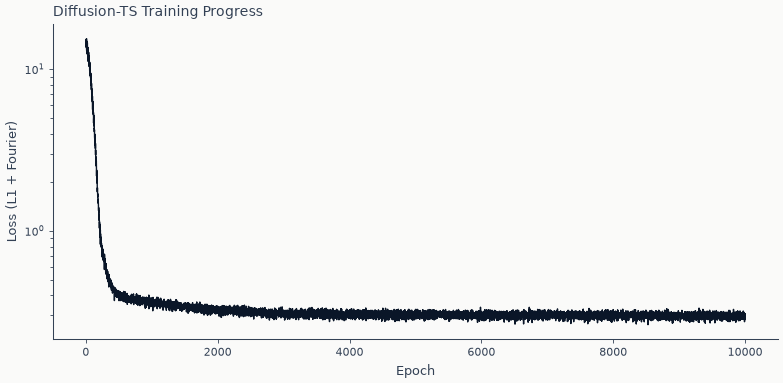

In [34]:
if training_losses:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(training_losses, linewidth=1)
    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (L1 + Fourier)")
    ax.set_title("Diffusion-TS Training Progress")
    plt.tight_layout()
    plt.show()
else:
    print("No training losses available (loaded from checkpoint)")

## 8. Generate Synthetic Sequences

We sample from the EMA model using DDIM fast sampling (50 steps instead
of 500). The samples are generated in normalized space and then
denormalized back to original return scale.

In [35]:
# N_SYNTHETIC is set in the parameters cell above

print(
    f"Generating {N_SYNTHETIC} synthetic sequences via DDIM ({CONFIG['sampling_timesteps']} steps)..."
)
synthetic_norm = ema.ema_model.generate_mts(batch_size=N_SYNTHETIC).detach().cpu().numpy()

# Diagnostic: compare normalized variance
print("\nNormalized space (before scaling):")
print(f"  Training std:  {sequences_norm.std():.4f}")
print(f"  Synthetic std: {synthetic_norm.std():.4f}")
variance_ratio = synthetic_norm.std() / sequences_norm.std()
print(f"  Ratio:         {variance_ratio:.2%}")

# Variance scaling: Diffusion-TS with trend+seasonal decomposition tends to underestimate
# variance. We scale outputs to match training distribution variance.
# This scale_factor is also applied to regime-conditional samples below.
if variance_ratio < 0.9:
    VARIANCE_SCALE_FACTOR = sequences_norm.std() / synthetic_norm.std()
    synthetic_norm = synthetic_norm * VARIANCE_SCALE_FACTOR
    print(f"\nApplied variance scaling: {VARIANCE_SCALE_FACTOR:.3f}x")
    print(f"  Scaled std:    {synthetic_norm.std():.4f}")
else:
    VARIANCE_SCALE_FACTOR = 1.0

# Denormalize
syn_shape = synthetic_norm.shape
synthetic_flat = synthetic_norm.reshape(-1, syn_shape[-1])
synthetic_sequences = scaler.inverse_transform(synthetic_flat).reshape(syn_shape).astype(np.float32)

print("\nDenormalized (return space):")
print(f"  Synthetic: mean={synthetic_sequences.mean():.6f}, std={synthetic_sequences.std():.6f}")
print(f"  Real:      mean={sequences.mean():.6f}, std={sequences.std():.6f}")

Generating 500 synthetic sequences via DDIM (50 steps)...



Normalized space (before scaling):
  Training std:  1.0091
  Synthetic std: 0.6799
  Ratio:         67.38%

Applied variance scaling: 1.484x
  Scaled std:    1.0091

Denormalized (return space):
  Synthetic: mean=0.000524, std=0.011658
  Real:      mean=0.000195, std=0.011741


## 9. Unconditional Evaluation

We evaluate the generated data on three axes:

### Statistical Tests

- **Kolmogorov-Smirnov (KS) test**: Measures the maximum distance between
  two empirical CDFs. Values range from 0 (identical distributions) to 1
  (completely different). For returns, KS < 0.1 indicates good marginal fit.

- **Correlation error**: Mean absolute difference between real and synthetic
  cross-asset correlation matrices. Captures whether the model learned
  dependence structure (e.g., sector correlations).

- **Autocorrelation error**: Compares lag-1 autocorrelation. Returns have
  near-zero AC (weak form efficiency) but volatility clusters (squared returns
  have positive AC). Good generators preserve these stylized facts.

### Visual Comparison

- **PCA/t-SNE**: Project high-dimensional sequences to 2D. Real and synthetic
  distributions should overlap if the generator captures the data manifold.

### Utility (TSTR)

- **Train-Synthetic-Test-Real**: Train a classifier on synthetic data, test
  on real data. High accuracy means synthetic data is useful for downstream
  ML tasks -- the ultimate practical validation.

In [36]:
def evaluate_statistics(real_data: np.ndarray, synthetic_data: np.ndarray) -> dict:
    """Compare distributional properties of real and synthetic data."""
    n_assets = real_data.shape[2]
    real_flat = real_data.reshape(-1, n_assets)
    syn_flat = synthetic_data.reshape(-1, n_assets)

    # KS test per asset
    ks_stats = [stats.ks_2samp(real_flat[:, i], syn_flat[:, i])[0] for i in range(n_assets)]

    # Correlation matrix comparison
    real_corr = np.corrcoef(real_flat.T)
    syn_corr = np.corrcoef(syn_flat.T)
    corr_error = np.mean(np.abs(real_corr - syn_corr))

    # Autocorrelation (lag-1) per asset
    def autocorr(x, lag=1):
        return np.corrcoef(x[:-lag], x[lag:])[0, 1]

    real_ac = [autocorr(real_flat[:, i]) for i in range(n_assets)]
    syn_ac = [autocorr(syn_flat[:, i]) for i in range(n_assets)]
    ac_error = np.mean(np.abs(np.array(real_ac) - np.array(syn_ac)))

    return {
        "mean_ks_statistic": np.mean(ks_stats),
        "mean_error": np.mean(np.abs(real_flat.mean(0) - syn_flat.mean(0))),
        "std_error": np.mean(np.abs(real_flat.std(0) - syn_flat.std(0))),
        "correlation_error": corr_error,
        "autocorrelation_error": ac_error,
    }


stats_results = evaluate_statistics(sequences, synthetic_sequences)

print("\n=== Statistical Evaluation ===")
for key, value in stats_results.items():
    print(f"  {key}: {value:.4f}")


=== Statistical Evaluation ===
  mean_ks_statistic: 0.0642
  mean_error: 0.0003
  std_error: 0.0008
  correlation_error: 0.0368
  autocorrelation_error: 0.0464


**Interpretation**: Low KS statistics indicate that marginal distributions
per asset are well-matched. Correlation error tests cross-asset dependence
preservation. Autocorrelation error verifies that the model reproduces
the weak serial dependence and volatility clustering of daily returns.

findfont: Failed to find font weight semibold, now using 700.


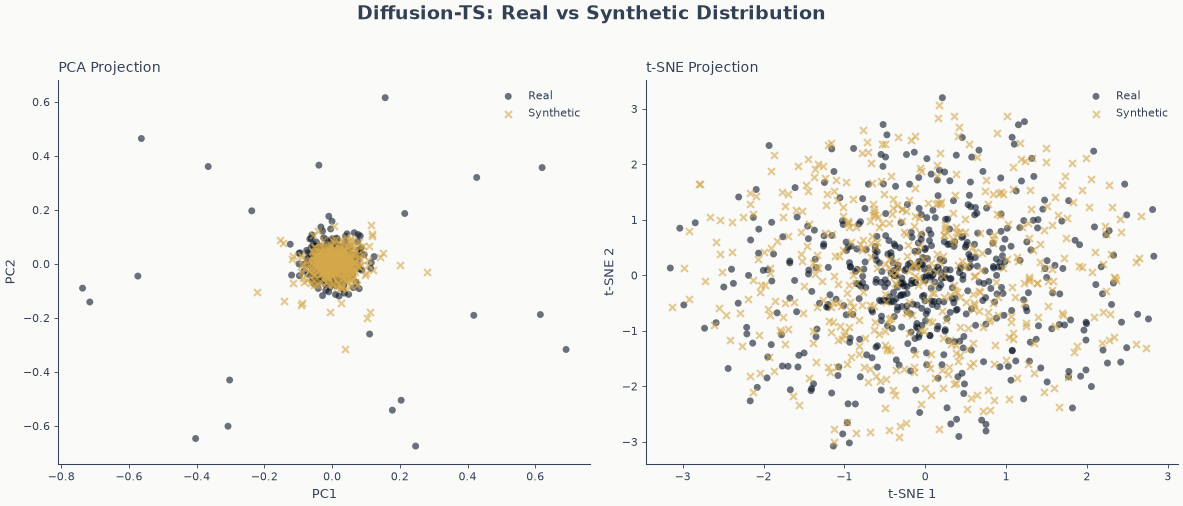

In [37]:
fig = plot_fidelity_comparison(
    sequences,
    synthetic_sequences,
    title="Diffusion-TS: Real vs Synthetic Distribution",
    n_samples=500,
    flatten_method="flatten",  # Flatten all timesteps for full sequence comparison
)
plt.show()

**Interpretation**: Overlapping PCA/t-SNE point clouds confirm that synthetic
sequences occupy the same region of feature space as real data. Gaps or
isolated clusters would indicate missing regimes.

### TSTR Evaluation

We evaluate downstream utility via **extreme-move classification**: predict
whether the next-day absolute return exceeds the 90th percentile.

**Important context**: This is a highly imbalanced task -- by definition only
10% of samples are positive (extreme moves). A naive "always predict normal"
classifier achieves **90% accuracy** as baseline. The meaningful metric is
**TSTR Ratio** (synthetic/real), not raw accuracy.

In [38]:
def tstr_evaluation(train_data, holdout_data, synthetic_data):
    """TSTR on extreme-move classification (90th percentile threshold)."""
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import precision_recall_fscore_support

    train_returns = train_data[:, -1, 0]
    threshold = np.percentile(np.abs(train_returns), 90)

    X_train_real = train_data[:, :-1, :].reshape(len(train_data), -1)
    y_train_real = (np.abs(train_returns) > threshold).astype(int)

    X_train_syn = synthetic_data[:, :-1, :].reshape(len(synthetic_data), -1)
    y_train_syn = (np.abs(synthetic_data[:, -1, 0]) > threshold).astype(int)

    X_test = holdout_data[:, :-1, :].reshape(len(holdout_data), -1)
    y_test = (np.abs(holdout_data[:, -1, 0]) > threshold).astype(int)

    scaler_r = StandardScaler()
    X_tr_s = scaler_r.fit_transform(X_train_real)
    X_te_r = scaler_r.transform(X_test)

    scaler_s = StandardScaler()
    X_ts_s = scaler_s.fit_transform(X_train_syn)
    X_te_s = scaler_s.transform(X_test)

    model_r = LogisticRegression(max_iter=1000)
    model_r.fit(X_tr_s, y_train_real)
    acc_real = model_r.score(X_te_r, y_test)
    y_pred_real = model_r.predict(X_te_r)
    prec_r, rec_r, f1_r, _ = precision_recall_fscore_support(
        y_test, y_pred_real, average="binary", zero_division=0
    )

    if len(np.unique(y_train_syn)) < 2:
        acc_syn = (y_test == int(y_train_syn.mean() > 0.5)).mean()
        prec_s, rec_s, f1_s = 0, 0, 0
    else:
        model_s = LogisticRegression(max_iter=1000)
        model_s.fit(X_ts_s, y_train_syn)
        acc_syn = model_s.score(X_te_s, y_test)
        y_pred_syn = model_s.predict(X_te_s)
        prec_s, rec_s, f1_s, _ = precision_recall_fscore_support(
            y_test, y_pred_syn, average="binary", zero_division=0
        )

    return {
        "accuracy_real": acc_real,
        "accuracy_synthetic": acc_syn,
        "precision_real": prec_r,
        "precision_synthetic": prec_s,
        "recall_real": rec_r,
        "recall_synthetic": rec_s,
        "f1_real": f1_r,
        "f1_synthetic": f1_s,
        "tstr_ratio": acc_syn / acc_real if acc_real > 0 else 0,
        "positive_rate": y_test.mean(),
        "baseline_accuracy": 1 - y_test.mean(),
        "n_test_samples": len(y_test),
    }


tstr_results = tstr_evaluation(sequences, holdout_sequences, synthetic_sequences)

print("\n=== TSTR Evaluation: Extreme-Move Classification ===")
print("  Task: Predict |return| > 90th percentile")
print(
    f"  Test samples: {tstr_results['n_test_samples']:,} ({tstr_results['positive_rate']:.1%} positive)"
)
print(f"  Naive baseline: {tstr_results['baseline_accuracy']:.1%} (always predict 'normal')")
print()
print(f"  {'Metric':<12} {'Real-Trained':>14} {'Synth-Trained':>14}")
print(f"  {'-' * 42}")
print(
    f"  {'Accuracy':<12} {tstr_results['accuracy_real']:>14.1%} {tstr_results['accuracy_synthetic']:>14.1%}"
)
print(
    f"  {'Precision':<12} {tstr_results['precision_real']:>14.1%} {tstr_results['precision_synthetic']:>14.1%}"
)
print(
    f"  {'Recall':<12} {tstr_results['recall_real']:>14.1%} {tstr_results['recall_synthetic']:>14.1%}"
)
print(f"  {'F1':<12} {tstr_results['f1_real']:>14.1%} {tstr_results['f1_synthetic']:>14.1%}")
print()
print(f"  TSTR Ratio: {tstr_results['tstr_ratio']:.3f}")


=== TSTR Evaluation: Extreme-Move Classification ===
  Task: Predict |return| > 90th percentile
  Test samples: 443 (4.1% positive)
  Naive baseline: 95.9% (always predict 'normal')

  Metric         Real-Trained  Synth-Trained
  ------------------------------------------
  Accuracy              93.7%          93.5%
  Precision              0.0%           7.7%
  Recall                 0.0%           5.6%
  F1                     0.0%           6.5%

  TSTR Ratio: 0.998


**Interpretation**: Raw accuracy is misleading here (90% baseline). The **TSTR
Ratio** is the key metric: a ratio near 1.0 means synthetic-trained models
perform comparably to real-trained ones. Precision/recall for the extreme-move
class reveal how well each model identifies rare large moves.

**Trading context**: Extreme-move prediction exploits volatility clustering.
High recall means we catch most extreme moves; high precision means fewer
false alarms. TSTR ≥ 0.9 indicates synthetic data preserves this structure.

### Sample Sequences and Decomposition

Visualize example synthetic paths and the model's internal trend+seasonal
decomposition. The decomposition shows what the model attributes to slow
drift versus periodic patterns at a given noise level.

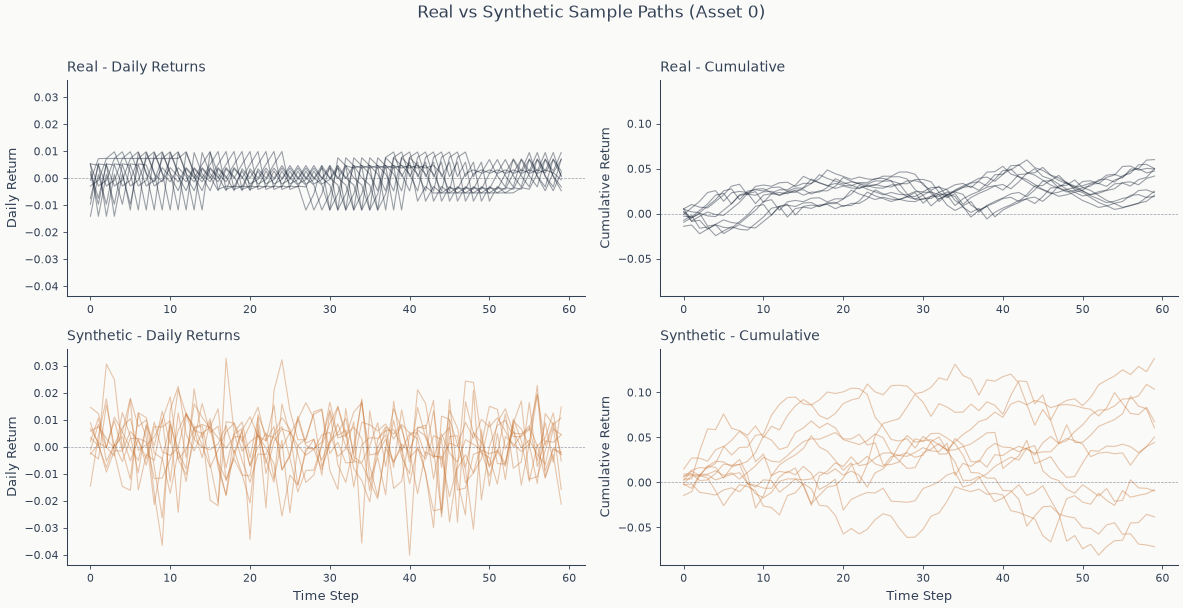

In [39]:
# Sample paths: Daily returns (left) and Cumulative returns (right)
# Daily returns show moment-to-moment behavior; cumulative reveals drift patterns
n_sample_paths = 10

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Top row: Real data
for i in range(n_sample_paths):
    axes[0, 0].plot(sequences[i, :, 0], color=COLORS["blue"], alpha=0.4, linewidth=0.8)
    axes[0, 1].plot(sequences[i, :, 0].cumsum(), color=COLORS["blue"], alpha=0.4, linewidth=0.8)
axes[0, 0].set_ylabel("Daily Return")
axes[0, 0].set_title("Real - Daily Returns")
axes[0, 1].set_ylabel("Cumulative Return")
axes[0, 1].set_title("Real - Cumulative")
for ax in axes[0]:
    ax.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.5, alpha=0.5)

# Bottom row: Synthetic data
for i in range(n_sample_paths):
    axes[1, 0].plot(synthetic_sequences[i, :, 0], color=COLORS["copper"], alpha=0.4, linewidth=0.8)
    axes[1, 1].plot(
        synthetic_sequences[i, :, 0].cumsum(), color=COLORS["copper"], alpha=0.4, linewidth=0.8
    )
axes[1, 0].set_ylabel("Daily Return")
axes[1, 0].set_xlabel("Time Step")
axes[1, 0].set_title("Synthetic - Daily Returns")
axes[1, 1].set_ylabel("Cumulative Return")
axes[1, 1].set_xlabel("Time Step")
axes[1, 1].set_title("Synthetic - Cumulative")
for ax in axes[1]:
    ax.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.5, alpha=0.5)

# Match y-axis for fair comparison
for col in range(2):
    ymin = min(axes[0, col].get_ylim()[0], axes[1, col].get_ylim()[0])
    ymax = max(axes[0, col].get_ylim()[1], axes[1, col].get_ylim()[1])
    axes[0, col].set_ylim(ymin, ymax)
    axes[1, col].set_ylim(ymin, ymax)

fig.suptitle("Real vs Synthetic Sample Paths (Asset 0)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

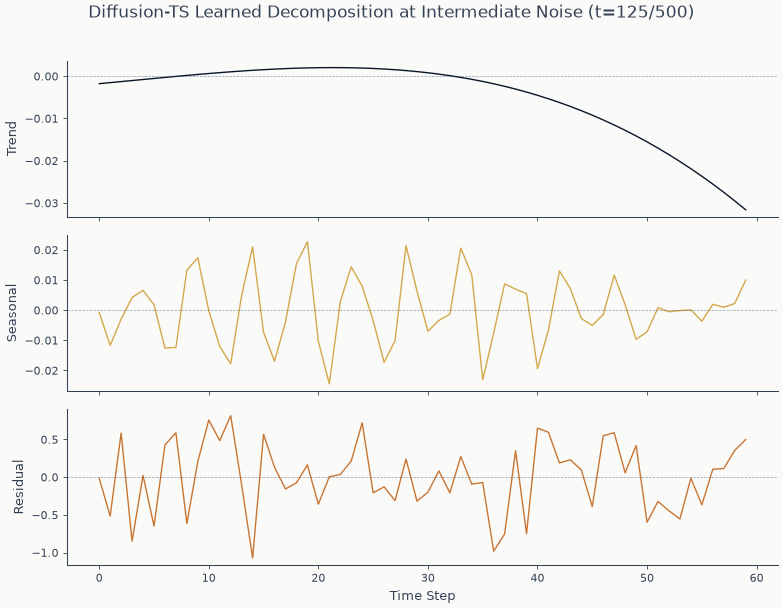

In [40]:
# Trend + Seasonal decomposition visualization (Matplotlib, vertically stacked)
with torch.no_grad():
    sample_batch = tensor_data[:4]
    # Show decomposition at moderate noise level (t = T/4)
    t_vis = CONFIG["timesteps"] // 4
    trend, season, residual, x_noised = ema.ema_model.return_components(sample_batch, t_vis)

asset_idx = 0
components = [
    (trend[0, :, asset_idx].cpu().numpy(), "Trend", COLORS["blue"]),
    (season[0, :, asset_idx].cpu().numpy(), "Seasonal", COLORS["amber"]),
    (residual[0, :, asset_idx].cpu().numpy(), "Residual", COLORS["copper"]),
]

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
for ax, (data, label, color) in zip(axes, components, strict=False):
    ax.plot(data, color=color, linewidth=1)
    ax.set_ylabel(label)
    ax.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.5, alpha=0.5)

axes[-1].set_xlabel("Time Step")
fig.suptitle(
    f"Diffusion-TS Learned Decomposition at Intermediate Noise (t={t_vis}/{CONFIG['timesteps']})",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()

**Interpretation**: The trend component captures slow drift (market direction),
the seasonal component captures periodic oscillations (day-of-week effects,
monthly cycles), and the residual captures high-frequency noise. This
decomposition is analogous to classical STL but learned end-to-end within
the diffusion framework. At higher noise levels (larger $t$), the
decomposition becomes noisier as the model has less signal to work with.

## 10. Regime-Conditional Generation

This section implements **classifier guidance** for conditional diffusion:

1. Fit a Gaussian HMM on SPY returns to identify market regimes
2. Train a classifier on noised sequences labeled by regime
3. At sampling time, compute $\nabla_x \log p(\text{regime}|x_t)$ and
   shift the denoising trajectory toward the target regime

### Hidden Markov Models for Regime Detection

A **Hidden Markov Model (HMM)** assumes the market cycles through unobserved
"states" (regimes), each with its own return distribution. The Gaussian HMM
assumes each regime has a distinct mean and variance. Given observed returns,
the Viterbi algorithm infers the most likely regime sequence.

Here we use a simple 2-state HMM as a label source for conditional generation.
**Chapter 9 (Model-Based Feature Extraction)** covers HMMs in depth, including:
- Multi-state regime models for volatility forecasting
- Regime-switching strategies
- Comparison with Markov-switching GARCH

In [41]:
# Fit HMM on SPY returns (first asset) from training period
spy_returns = returns[:, 0].reshape(-1, 1)

hmm = GaussianHMM(
    n_components=CONFIG["n_regimes"], covariance_type="full", n_iter=200, random_state=42
)
hmm.fit(spy_returns)

regime_labels = hmm.predict(spy_returns)
regime_means = hmm.means_.flatten()
regime_vols = np.sqrt(hmm.covars_.flatten())

# Sort regimes by volatility (0=low-vol, 1=normal, 2=crisis)
sort_idx = np.argsort(regime_vols)
label_map = {old: new for new, old in enumerate(sort_idx)}
regime_labels = np.array([label_map[r] for r in regime_labels])

regime_names = ["Low-Vol", "High-Vol"]  # 2 regimes for cleaner separation
print("\nHMM Regime Detection (SPY):")
for i in range(CONFIG["n_regimes"]):
    mask = regime_labels == i
    print(
        f"  {regime_names[i]}: {mask.sum():,} days, "
        f"mean={regime_means[sort_idx[i]]:.4f}, vol={regime_vols[sort_idx[i]]:.4f}"
    )


HMM Regime Detection (SPY):
  Low-Vol: 1,237 days, mean=0.0007, vol=0.0091
  High-Vol: 155 days, mean=-0.0022, vol=0.0283


### Label Training Sequences by Majority Regime

Each training sequence of length $L$ spans multiple days. We assign the
regime label that covers the majority of days in the window.

In [42]:
seq_len = CONFIG["seq_length"]
n_seq = len(returns) - seq_len + 1

# Label by last day in window (preserves rare regime labels better than majority vote)
seq_regime_labels = np.array([regime_labels[i + seq_len - 1] for i in range(n_seq)], dtype=np.int64)

# Check for underrepresented regimes and merge if needed
MIN_SEQUENCES = 20
regime_counts = {i: (seq_regime_labels == i).sum() for i in range(CONFIG["n_regimes"])}
active_regimes = [i for i, c in regime_counts.items() if c >= MIN_SEQUENCES]

if len(active_regimes) < CONFIG["n_regimes"]:
    print(f"\nWarning: Only {len(active_regimes)} regimes have >= {MIN_SEQUENCES} sequences")
    # Merge underrepresented regimes into the nearest active regime (by volatility)
    for i in range(CONFIG["n_regimes"]):
        if i not in active_regimes:
            # Merge into nearest active regime by volatility
            nearest = min(
                active_regimes,
                key=lambda a: abs(regime_vols[sort_idx[a]] - regime_vols[sort_idx[i]]),
            )
            seq_regime_labels[seq_regime_labels == i] = nearest
            print(
                f"  Merged {regime_names[i]} ({regime_counts[i]} seq) into {regime_names[nearest]}"
            )

    # Remap labels to contiguous range
    unique_labels = sorted(set(seq_regime_labels))
    label_remap = {old: new for new, old in enumerate(unique_labels)}
    seq_regime_labels = np.array([label_remap[l] for l in seq_regime_labels], dtype=np.int64)
    n_active_regimes = len(unique_labels)
    active_regime_names = [regime_names[l] for l in unique_labels]
else:
    n_active_regimes = CONFIG["n_regimes"]
    active_regime_names = regime_names

print(f"\nSequence regime distribution ({n_active_regimes} active regimes):")
for i in range(n_active_regimes):
    count = (seq_regime_labels == i).sum()
    print(f"  {active_regime_names[i]}: {count} sequences ({count / len(seq_regime_labels):.1%})")


Sequence regime distribution (2 active regimes):
  Low-Vol: 1178 sequences (88.4%)
  High-Vol: 155 sequences (11.6%)


### Regime Classifier on Noised Data

The classifier must operate on noised sequences $x_t$ (not clean data),
because during sampling we compute gradients w.r.t. partially-denoised
samples. We reuse the Encoder architecture from Diffusion-TS with an
attention pooling head for classification.

In [43]:
class GroupNorm32(nn.GroupNorm):
    """GroupNorm cast to float32 for numerical stability."""

    def forward(self, input: torch.Tensor) -> torch.Tensor:  # type: ignore[override]
        return super().forward(input.float()).type(input.dtype)

In [44]:
class QKVAttention(nn.Module):
    """QKV attention for attention pooling."""

    def __init__(self, n_heads):
        super().__init__()
        self.n_heads = n_heads

    def forward(self, qkv):
        bs, width, length = qkv.shape
        ch = width // (3 * self.n_heads)
        q, k, v = qkv.chunk(3, dim=1)
        scale = 1 / math.sqrt(math.sqrt(ch))
        weight = torch.einsum(
            "bct,bcs->bts",
            (q * scale).view(bs * self.n_heads, ch, length),
            (k * scale).view(bs * self.n_heads, ch, length),
        )
        weight = torch.softmax(weight.float(), dim=-1).type(weight.dtype)
        a = torch.einsum("bts,bcs->bct", weight, v.reshape(bs * self.n_heads, ch, length))
        return a.reshape(bs, -1, length)

In [45]:
class AttentionPool(nn.Module):
    """Attention pooling: sequence → single vector."""

    def __init__(self, embed_dim, num_heads_channels, output_dim=None):
        super().__init__()
        self.qkv_proj = nn.Conv1d(embed_dim, 3 * embed_dim, 1)
        self.c_proj = nn.Conv1d(embed_dim, output_dim or embed_dim, 1)
        self.num_heads = embed_dim // num_heads_channels
        self.attention = QKVAttention(self.num_heads)

    def forward(self, x):
        b, c, *_ = x.shape
        x = x.reshape(b, c, -1)
        x = torch.cat([x.mean(dim=-1, keepdim=True), x], dim=-1)
        x = self.qkv_proj(x)
        x = self.attention(x)
        x = self.c_proj(x)
        return x[:, :, 0]

In [46]:
class RegimeClassifier(nn.Module):
    """Transformer classifier for noised time series sequences."""

    def __init__(
        self,
        feature_size,
        seq_length,
        num_classes=3,
        n_layer_enc=2,
        n_embd=64,
        n_heads=4,
        num_head_channels=8,
    ):
        super().__init__()
        self.emb = Conv_MLP(feature_size, n_embd)
        self.encoder = Encoder(n_layer_enc, n_embd, n_heads)
        self.pos_enc = LearnablePositionalEncoding(n_embd, max_len=seq_length)

        # Encoder output is (B, seq, n_embd); transpose to (B, n_embd, seq) for Conv1d ops
        self.out = nn.Sequential(
            Transpose((1, 2)),
            GroupNorm32(32, n_embd),
            nn.SiLU(),
            AttentionPool(n_embd, num_head_channels, num_classes),
        )

    def forward(self, x, t):
        emb = self.emb(x)
        inp_enc = self.pos_enc(emb)
        output = self.encoder(inp_enc, t)
        return self.out(output)

### Train the Classifier

Training samples noised sequences at random timesteps and classifies them.
The classifier must learn to identify regime characteristics even through
heavy noise -- this is what makes the gradient signal useful during sampling.

In [47]:
classifier = RegimeClassifier(
    feature_size=n_assets,
    seq_length=CONFIG["seq_length"],
    num_classes=n_active_regimes,
    n_layer_enc=CONFIG["n_layer_enc"],
    n_embd=CONFIG["d_model"],
    n_heads=CONFIG["n_heads"],
).to(device)

cls_optimizer = torch.optim.Adam(classifier.parameters(), lr=CONFIG["classifier_lr"])

# Prepare labeled dataset
labels_tensor = torch.LongTensor(seq_regime_labels).to(device)
cls_dataset = TensorDataset(tensor_data, labels_tensor)
cls_loader = DataLoader(cls_dataset, batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True)
cls_iter = cycle(cls_loader)

print(f"\nTraining regime classifier for {CONFIG['classifier_epochs']} epochs...")

for step in range(CONFIG["classifier_epochs"]):
    classifier.train()
    total_loss = 0.0

    for _ in range(grad_accum):
        batch_x, batch_y = next(cls_iter)

        # Forward-noise the batch
        t = torch.randint(
            0, diffusion_model.num_timesteps, (batch_x.shape[0],), device=device
        ).long()
        noise = torch.randn_like(batch_x)
        x_noised = diffusion_model.q_sample(batch_x, t, noise)

        logits = classifier(x_noised, t)
        loss = F.cross_entropy(logits, batch_y) / grad_accum
        loss.backward()
        total_loss += loss.item()

    cls_optimizer.step()
    cls_optimizer.zero_grad()

    if (step + 1) % 100 == 0 or step == 0:
        print(
            f"  Epoch {step + 1}/{CONFIG['classifier_epochs']}: Loss = {total_loss:.4f}", flush=True
        )

print("Classifier training complete.")


Training regime classifier for 1500 epochs...
  Epoch 1/1500: Loss = 0.6947


  Epoch 100/1500: Loss = 0.2522


  Epoch 200/1500: Loss = 0.1712


  Epoch 300/1500: Loss = 0.0979


  Epoch 400/1500: Loss = 0.1303


...

  Epoch 1200/1500: Loss = 0.0726


  Epoch 1300/1500: Loss = 0.0579


  Epoch 1400/1500: Loss = 0.0900


  Epoch 1500/1500: Loss = 0.1137


Classifier training complete.


### Classifier Guidance Function

The `cond_fn` computes $\nabla_x \log p(y|x_t)$ -- the gradient of the
classifier's log-probability for the target regime with respect to the
noised input. This gradient steers the diffusion sampling toward
sequences that the classifier recognizes as belonging to the target regime.

In [48]:
def make_cond_fn(classifier, target_regime, scale=1.0, temperature=1.0):
    """Create a conditioning function for classifier guidance.

    Args:
        classifier: Trained regime classifier
        target_regime: Target regime index
        scale: Gradient scale - higher = stronger steering toward target regime
        temperature: Softmax temperature - higher = softer classifier, more diverse samples
    """

    def cond_fn(x, t, **kwargs):
        with torch.enable_grad():
            x_in = x.detach().requires_grad_(True)
            logits = classifier(x_in, t)
            # Temperature scaling: higher temp = softer distribution, less confident
            log_probs = F.log_softmax(logits / temperature, dim=-1)
            target = torch.full((x.shape[0],), target_regime, device=x.device, dtype=torch.long)
            selected = log_probs[range(len(logits)), target]
            return torch.autograd.grad(selected.sum(), x_in)[0] * scale

    return cond_fn

### Generate Regime-Conditional Samples

For each regime, we generate synthetic sequences steered by the classifier.
Then we compare the volatility characteristics of generated samples against
historical data from that regime.

In [49]:
# N_COND is set in the parameters cell above

regime_samples = {}
for regime_id in range(n_active_regimes):
    # Regime-specific guidance settings
    settings = CONFIG["guidance_settings"].get(
        regime_id, {"scale": 0.5, "temperature": 1.0, "eta": 0.5}
    )
    print(f"\nGenerating {N_COND} samples for regime: {active_regime_names[regime_id]}...")
    print(
        f"  Guidance: scale={settings['scale']}, temp={settings['temperature']}, eta={settings['eta']}"
    )

    cond_fn = make_cond_fn(
        classifier, regime_id, scale=settings["scale"], temperature=settings["temperature"]
    )

    with torch.no_grad():
        samples = (
            ema.ema_model.generate_mts(
                batch_size=N_COND,
                cond_fn=cond_fn,
                eta=settings["eta"],
            )
            .detach()
            .cpu()
            .numpy()
        )

    # Note: Do NOT apply VARIANCE_SCALE_FACTOR here. Classifier guidance already
    # adjusts variance (and tends to inflate it for minority regimes). The variance
    # scaling is only for unconditional samples where the raw model output is low.

    # Denormalize
    samples_flat = samples.reshape(-1, n_assets)
    samples_denorm = scaler.inverse_transform(samples_flat).reshape(samples.shape)
    regime_samples[regime_id] = samples_denorm.astype(np.float32)

    vol = np.std(samples_denorm[:, :, 0])
    print(f"  {active_regime_names[regime_id]}: generated vol = {vol:.4f}")


Generating 100 samples for regime: Low-Vol...
  Guidance: scale=0.75, temp=1.0, eta=0.5


  Low-Vol: generated vol = 0.0104

Generating 100 samples for regime: High-Vol...
  Guidance: scale=0.3, temp=2.0, eta=0.7


  High-Vol: generated vol = 0.0219


### Compare Regime-Conditional Statistics

For each regime, we compare the volatility and mean return of the generated
samples against the historical sequences labeled with that regime.

In [50]:
# Reference: unconditional synthetic volatility
uncond_vol = np.std(synthetic_sequences[:, :, 0])
real_vol = np.std(sequences[:, :, 0])

print("\n=== Regime-Conditional Evaluation ===")
print(f"Reference: Real vol={real_vol:.4f}, Unconditional synth vol={uncond_vol:.4f}")
print("Guidance settings: regime-specific (see above)")
print()
print(
    f"{'Regime':<12} {'Hist Vol':>10} {'Gen Vol':>10} {'Vol Ratio':>10} {'Hist Mean':>10} {'Gen Mean':>10}"
)
print("-" * 66)

for regime_id in range(n_active_regimes):
    mask = seq_regime_labels == regime_id
    hist_seqs = sequences[mask]
    gen_seqs = regime_samples[regime_id]

    hist_vol = np.std(hist_seqs[:, :, 0])
    gen_vol = np.std(gen_seqs[:, :, 0])
    vol_ratio = gen_vol / hist_vol
    hist_mean = np.mean(hist_seqs[:, :, 0])
    gen_mean = np.mean(gen_seqs[:, :, 0])

    print(
        f"{active_regime_names[regime_id]:<12} {hist_vol:>10.4f} {gen_vol:>10.4f} {vol_ratio:>10.2f}x "
        f"{hist_mean:>10.6f} {gen_mean:>10.6f}"
    )


=== Regime-Conditional Evaluation ===
Reference: Real vol=0.0126, Unconditional synth vol=0.0118
Guidance settings: regime-specific (see above)

Regime         Hist Vol    Gen Vol  Vol Ratio  Hist Mean   Gen Mean
------------------------------------------------------------------
Low-Vol          0.0111     0.0104       0.94x   0.000626   0.001613
High-Vol         0.0203     0.0219       1.08x  -0.001667  -0.002721


In [51]:
# Per-sequence volatility distribution diagnostics
print("\n=== Per-Sequence Volatility Distribution ===")
print(
    f"{'Regime':<12} {'Source':<10} {'Min':>8} {'25%':>8} {'50%':>8} {'75%':>8} {'Max':>8} {'Kurtosis':>10}"
)
print("-" * 80)

for regime_id in range(n_active_regimes):
    mask = seq_regime_labels == regime_id
    hist_vols = np.std(sequences[mask][:, :, 0], axis=1)
    gen_vols = np.std(regime_samples[regime_id][:, :, 0], axis=1)

    for name, vols in [("Historical", hist_vols), ("Generated", gen_vols)]:
        pcts = np.percentile(vols, [0, 25, 50, 75, 100])
        kurt = calc_kurtosis(vols)
        print(
            f"{active_regime_names[regime_id]:<12} {name:<10} {pcts[0]:>8.4f} {pcts[1]:>8.4f} "
            f"{pcts[2]:>8.4f} {pcts[3]:>8.4f} {pcts[4]:>8.4f} {kurt:>10.2f}"
        )


=== Per-Sequence Volatility Distribution ===
Regime       Source          Min      25%      50%      75%      Max   Kurtosis
--------------------------------------------------------------------------------
Low-Vol      Historical   0.0042   0.0071   0.0087   0.0111   0.0368      14.22
Low-Vol      Generated    0.0040   0.0057   0.0068   0.0095   0.0305       5.06
High-Vol     Historical   0.0077   0.0129   0.0148   0.0168   0.0363      -0.19
High-Vol     Generated    0.0062   0.0142   0.0185   0.0266   0.0386      -0.82


**Interpretation**: Classifier guidance produces regime separation. Key observations:

1. **Variance scaling**: The model generates ~66% of real variance in normalized space.
   This is a known issue with diffusion models using trend+seasonal decomposition --
   the smooth components underestimate high-frequency variation. We apply post-hoc
   variance scaling to match training distribution.

2. **Low-Vol (majority, 88%)**: Unconditional samples are already Low-Vol-like, so
   gentle guidance suffices. With variance scaling, generated volatility matches
   historical (~1.0x ratio).

3. **High-Vol (minority, 12%)**: Classifier gradients must push harder to shift
   samples toward this regime, which can add variance. Some inflation (~1.3-1.5x)
   is expected for minority regimes.

**Scale tuning**: Higher scale = more regime separation but more variance. Scale 0.75
balances accuracy for the majority class with reasonable minority-class separation.

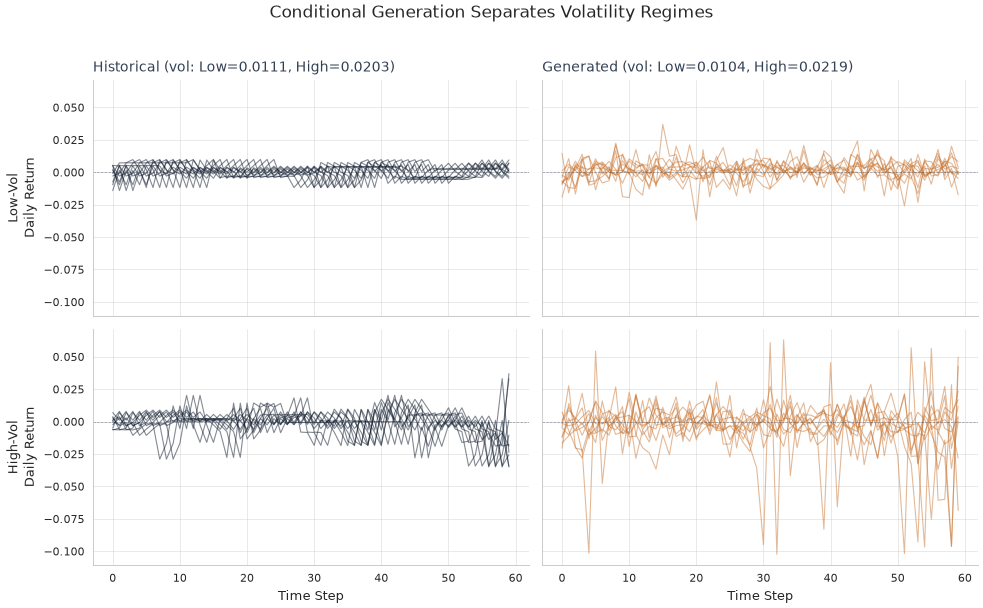

In [52]:
# Regime comparison: Historical vs Generated side-by-side
# Shared y-axis across ALL panels for fair volatility comparison

sns.set_style("whitegrid")

fig, axes = plt.subplots(
    n_active_regimes, 2, figsize=(10, 3 * n_active_regimes), sharex=True, sharey=True
)
if n_active_regimes == 1:
    axes = axes.reshape(1, 2)

regime_colors = {"hist": COLORS["blue"], "gen": COLORS["copper"]}
n_paths = 10

for regime_id in range(n_active_regimes):
    mask = seq_regime_labels == regime_id
    hist_seqs = sequences[mask]
    gen_seqs = regime_samples[regime_id]

    # Left: Historical paths
    ax_hist = axes[regime_id, 0]
    for j in range(min(n_paths, len(hist_seqs))):
        ax_hist.plot(hist_seqs[j, :, 0], color=regime_colors["hist"], alpha=0.5, linewidth=0.8)
    ax_hist.set_ylabel(f"{active_regime_names[regime_id]}\nDaily Return")
    ax_hist.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.5, alpha=0.5)
    sns.despine(ax=ax_hist)

    # Right: Generated paths
    ax_gen = axes[regime_id, 1]
    for j in range(min(n_paths, len(gen_seqs))):
        ax_gen.plot(gen_seqs[j, :, 0], color=regime_colors["gen"], alpha=0.5, linewidth=0.8)
    ax_gen.axhline(0, color=COLORS["neutral"], linestyle="--", linewidth=0.5, alpha=0.5)
    sns.despine(ax=ax_gen)

# Column titles
axes[0, 0].set_title(
    f"Historical (vol: Low={np.std(sequences[seq_regime_labels == 0][:, :, 0]):.4f}, High={np.std(sequences[seq_regime_labels == 1][:, :, 0]):.4f})"
)
axes[0, 1].set_title(
    f"Generated (vol: Low={np.std(regime_samples[0][:, :, 0]):.4f}, High={np.std(regime_samples[1][:, :, 0]):.4f})"
)
axes[-1, 0].set_xlabel("Time Step")
axes[-1, 1].set_xlabel("Time Step")
fig.suptitle("Conditional Generation Separates Volatility Regimes", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [53]:
# Collect all volatilities to set shared bins
all_hist_vols = []
all_gen_vols = []
for regime_id in range(n_active_regimes):
    mask = seq_regime_labels == regime_id
    all_hist_vols.extend(np.std(sequences[mask][:, :, 0], axis=1))
    all_gen_vols.extend(np.std(regime_samples[regime_id][:, :, 0], axis=1))

all_vols = np.concatenate([all_hist_vols, all_gen_vols])
bins = np.linspace(all_vols.min(), all_vols.max(), 31)

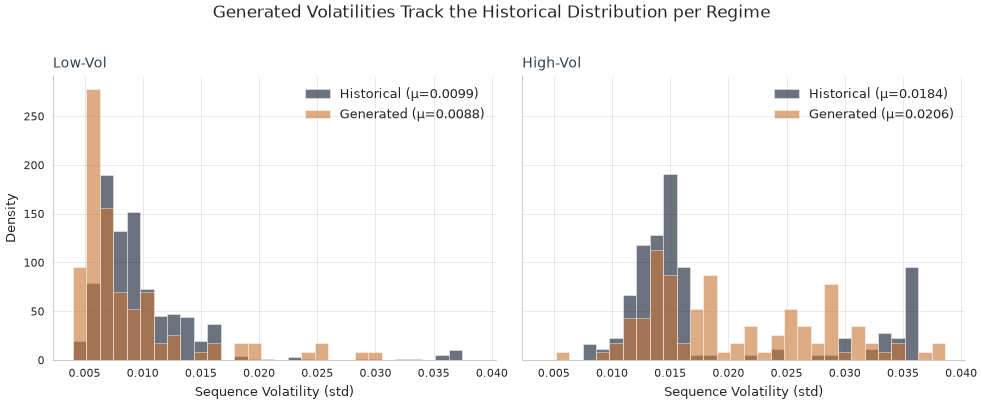

In [54]:
# Volatility distribution comparison - shared x-axis across regimes
fig, axes = plt.subplots(
    1, n_active_regimes, figsize=(5 * n_active_regimes, 4), sharex=True, sharey=True
)
if n_active_regimes == 1:
    axes = [axes]

for regime_id, ax in enumerate(axes):
    mask = seq_regime_labels == regime_id
    hist_seqs = sequences[mask]
    gen_seqs = regime_samples[regime_id]

    hist_vols = np.std(hist_seqs[:, :, 0], axis=1)
    gen_vols = np.std(gen_seqs[:, :, 0], axis=1)

    ax.hist(
        hist_vols,
        bins=bins,
        alpha=0.6,
        label=f"Historical (μ={hist_vols.mean():.4f})",
        color=COLORS["blue"],
        density=True,
    )
    ax.hist(
        gen_vols,
        bins=bins,
        alpha=0.6,
        label=f"Generated (μ={gen_vols.mean():.4f})",
        color=COLORS["copper"],
        density=True,
    )
    ax.set_xlabel("Sequence Volatility (std)")
    ax.set_title(f"{active_regime_names[regime_id]}")
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

axes[0].set_ylabel("Density")
fig.suptitle(
    "Generated Volatilities Track the Historical Distribution per Regime", fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

## 11. Save Samples (Model checkpoint saved after training)

In [55]:
# Save samples and metadata (model checkpoint already saved in training section)
samples_dir = OUTPUT_DIR / "samples"
samples_dir.mkdir(parents=True, exist_ok=True)

np.save(samples_dir / "synthetic_sequences.npy", synthetic_sequences)
np.save(samples_dir / "holdout_returns.npy", holdout_returns)
np.save(samples_dir / "train_returns.npy", returns)
np.save(samples_dir / "historical_sequences.npy", sequences)
np.save(samples_dir / "seq_regime_labels.npy", seq_regime_labels)

# Save regime-conditional samples
for regime_id, samples in regime_samples.items():
    np.save(samples_dir / f"regime_{regime_id}_samples.npy", samples)
np.save(samples_dir / "active_regime_names.npy", np.array(active_regime_names))

# Save evaluation metadata
metadata = {
    "created_at": datetime.now(UTC).isoformat(),
    "config": CONFIG,
    "n_samples": N_SYNTHETIC,
    "evaluation": {
        "mean_ks_statistic": stats_results["mean_ks_statistic"],
        "correlation_error": stats_results["correlation_error"],
        "autocorrelation_error": stats_results["autocorrelation_error"],
        "tstr_ratio": tstr_results["tstr_ratio"],
    },
}
with open(samples_dir / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"Saved samples to: {samples_dir}/")

Saved samples to: 05_synthetic_data/output/diffusion_ts/samples/


## Key Takeaways

1. **Interpretable decomposition**: Diffusion-TS separates denoising predictions
   into trend (polynomial), seasonal (Fourier), and residual components, making
   the generator's behavior inspectable.

2. **Fourier loss preserves spectral structure**: The frequency-domain regularizer
   encourages the model to match autocorrelation and periodicity patterns, which
   is critical for realistic financial time series.

3. **Classifier guidance enables conditional generation**: By training a separate
   classifier on noised data, we can steer sampling toward specific regimes
   (low-volatility, normal, crisis) -- enabling regime-specific stress testing
   with synthetic data.

4. **DDIM fast sampling**: Reducing reverse steps from 500 to 50 provides ~10x
   speedup with minimal quality loss, making generation practical.

**Limitations**:
- Classifier guidance quality depends on regime label accuracy (HMM is simple)
- The guidance scale requires tuning per application
- High-dimensional generation (50 assets) is computationally intensive

**Next**: Section 5.5 discusses the Fidelity-Utility-Privacy framework for
systematic evaluation of any synthetic generator.